In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mutual_info_score

# utils

## method to generate the time series of the MG model
using the fourth-order Runge-Kutta method with interpolation

In [3]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=23,theta=1,n=10,x0=0.2,N=1000000,delta=0.01,past_val=0.1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+past_val
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

## method to compute the Lyapunov Exponent

ref [nolds](https://cschoel.github.io/nolds/nolds.html#lyapunov-exponent-rosenstein-et-al), using the algorithm of [Rosenstein](https://physionet.org/files/lyapunov/1.0.0/RosensteinM93.pdf)

In [4]:
import nolds

In [25]:
T,X = MG_generate_interp(tau=40,x0=1)

In [26]:
X_tru= X[::100][4000:5000]

* min_tsep

Since the method in the nolds to compute the mean frequency use the zero padding, which loses the accuracy, we will write a method to compute the mean frequency for the parameter "min_tsep"

In [27]:
def mf_value(x):
    n = len(x)
    fft_vals = np.fft.rfft(x,n)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(n)
    # Skip DC component at index 0
    mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])
    return mean_freq
    

* lag

Here we use the method first minimum average mutual information provided [here](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.33.1134) to compute the optimal lag

In [28]:
def compute_ami_lag(x, max_lag=100, bins=32):
    """
    Estimate optimal embedding lag via average mutual information (AMI).
    Returns list of AMI values and the first local minimum lag.
    """
    # Discretize data into bins
    hist, bin_edges = np.histogram(x, bins=bins)
    digitized = np.digitize(x, bin_edges[:-1])
    
    ami = []
    for lag in range(1, max_lag):
        x1 = digitized[:-lag]
        x2 = digitized[lag:]
        mi = mutual_info_score(x1, x2)
        ami.append(mi)

    # Find the first local minimum
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
            return i + 1, ami  # +1 because lag starts at 1

    return np.argmin(ami) + 1, ami  # fallback if no local min


* lyapunov exponent

In [132]:
def compute_le(x):
    mf = mf_value(x)
    min_tsep = int(round(1/mf))
    lag,_ = compute_ami_lag(x,bins = 100)
    #print(min_tsep,lag)
    le = nolds.lyap_r(x,min_tsep=min_tsep,lag=lag)
    return le

# Test method stability

* lyapunov exponent

different start point with the same $x0$

In [153]:
np.random.seed(0)
les = []
_,X = MG_generate_interp(x0 =0.2,tau=100)
for i in range(1,500):
    start = i*10+4000
    X_tru= X[::100][start:start+500]
    le = compute_le(X_tru)
    les.append(le)

Text(0, 0.5, 'Lyapunov Exponent')

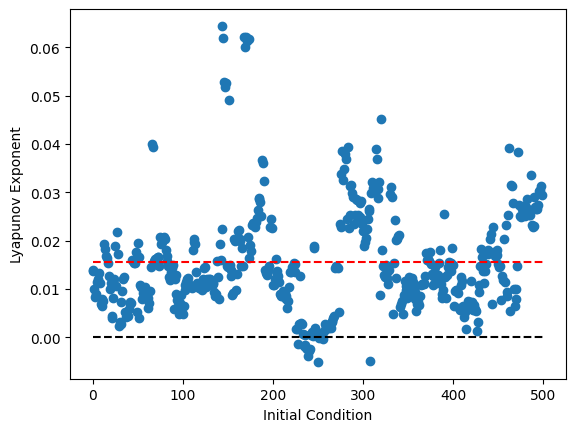

In [ ]:
mean = sum(les)/len(les)

plt.plot(les,"o")
plt.plot([0,500],[mean,mean],color = "red",linestyle = "--")
plt.plot([0,500],[0,0],color = "black",linestyle = "--")
plt.xlabel('start point')
plt.ylabel('Lyapunov Exponent')

different $x0$

In [156]:
np.random.seed(0)
les = []

for i in range(1,200):
    _,X = MG_generate_interp(x0 =(i+1)/2,tau=100)
    X_tru= X[::100][8000:8500]
    le = compute_le(X_tru)
    les.append(le)

Text(0, 0.5, 'Lyapunov Exponent')

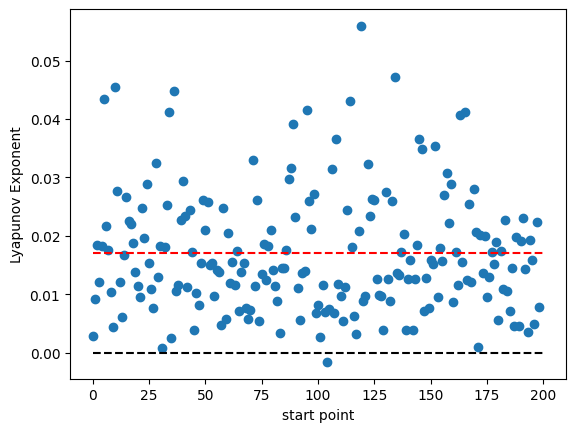

In [158]:
mean = sum(les)/len(les)
plt.plot(les,"o")
plt.plot([0,200],[mean,mean],color = "red",linestyle = "--")
plt.plot([0,200],[0,0],color = "black",linestyle = "--")
plt.xlabel('start point')
plt.ylabel('Lyapunov Exponent')

In [162]:
_,X = MG_generate_interp(x0 =0.2,tau=100)


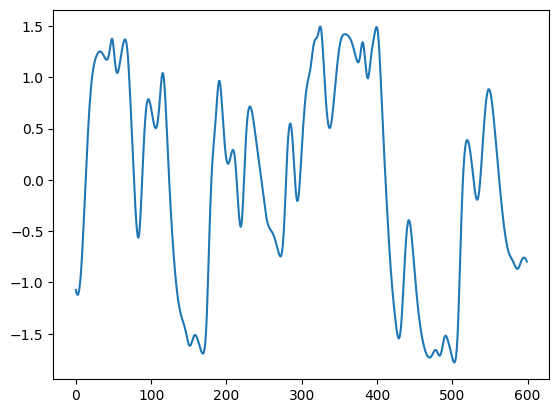

In [166]:
X_tru= X[::100][7200:7800]
X_tru = (X_tru - np.mean(X_tru))/np.std(X_tru)
plt.plot(X_tru)